# Gaussian Process Isopleth Surface Builder

This notebook mirrors the workflow of `RBF_Isopleth_Surface.ipynb` but fits a Gaussian Process Regression (GPR) model to create a smooth surface from isopleth samples. Edit the configuration cell, then run the sections top-to-bottom to refresh the fit, diagnostics, and plots.

## Quick Start
1. Update the `CONFIG` dictionary (data path, column names, parameter to model, GPR hyperparameters).
2. Run *Load & Prepare Data* to get clean predictor/response arrays.
3. Execute *Fit Gaussian Process Surface* to build the interpolated grid.
4. Check *K-Fold Evaluation* for cross-validated quality metrics.
5. Render the 2D contour, static 3D, and interactive 3D plots to inspect the surface.

In [33]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import ticker
from IPython.display import display
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, RationalQuadratic, ConstantKernel, WhiteKernel
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

plt.style.use('seaborn-v0_8-whitegrid')

In [68]:
CONFIG = {
    # Data + column settings -------------------------------------------------
    'data_path': Path('/Users/isaacsudweeks/Desktop/Work/Improved_Isopleths/data/utah/filtered_by_SR_data/filtered_max_nosmoke_all'),
    'lon_col': 'NOx',
    'lat_col': 'VOC',
    'value_col': 'Ozone',  # Change this to switch which parameter is modeled.
    'filters': {
        # Example: 'parameter': ['Carbon disulfide']
    },
    # Surface + evaluation settings -----------------------------------------
    'grid_resolution': 80,
    'kfold': {
        'splits': 5,
        'shuffle': True,
        'random_state': 42,
    },
    # Gaussian Process hyperparameters --------------------------------------
    'gpr': {
        'alpha': 0.3,
        'normalize_y': True,
        'n_restarts_optimizer': 2,
        'kernel': {
            'type': 'RBF',  # Options: 'RBF', 'Matern', 'RationalQuadratic'
            'length_scale': 3.0,
            'nu': 1.5,
            'length_scale_bounds': (1e-10, 1e10),
            'white_noise': 0.02,
            'constant': 1.3,
        },
    },
    # Plot styling -----------------------------------------------------------
    'plot': {
        'cmap': 'viridis',
        'contour_levels': 30,
        'point_size': 35,
        'surface_alpha': 0.85,
        'scatter_color': 'firebrick',
        'plotly_colorscale': 'Viridis',
    },
}


In [69]:
def build_kernel(kernel_cfg):
    kernel_cfg = kernel_cfg or {}
    kind = (kernel_cfg.get('type') or 'RBF').lower()
    length_scale = kernel_cfg.get('length_scale', 1.0)
    bounds = kernel_cfg.get('length_scale_bounds', (1e-2, 1e3))

    if kind == 'matern':
        base = Matern(length_scale=length_scale, length_scale_bounds=bounds, nu=kernel_cfg.get('nu', 1.5))
    elif kind == 'rationalquadratic':
        base = RationalQuadratic(length_scale=length_scale, alpha=kernel_cfg.get('alpha', 1.0))
    else:
        base = RBF(length_scale=length_scale, length_scale_bounds=bounds)

    constant = kernel_cfg.get('constant')
    if constant is not None:
        base = ConstantKernel(constant_value=constant) * base

    noise = kernel_cfg.get('white_noise')
    if noise is not None and noise > 0:
        base += WhiteKernel(noise_level=noise)

    return base


def make_gpr(gpr_cfg):
    gpr_cfg = dict(gpr_cfg)
    kernel_cfg = gpr_cfg.pop('kernel', {})
    kernel = build_kernel(kernel_cfg)
    return GaussianProcessRegressor(kernel=kernel, **gpr_cfg)


def evaluate_gpr_kfold(lon_array, lat_array, value_array, gpr_cfg, kfold_cfg):
    lon_array = np.asarray(lon_array, dtype=float)
    lat_array = np.asarray(lat_array, dtype=float)
    value_array = np.asarray(value_array, dtype=float)

    predictors = np.column_stack((lon_array, lat_array))
    kf = KFold(n_splits=kfold_cfg['splits'], shuffle=kfold_cfg.get('shuffle', False), random_state=kfold_cfg.get('random_state'))

    fold_rows = []
    for fold_id, (train_idx, test_idx) in enumerate(kf.split(predictors), start=1):
        gpr = make_gpr(gpr_cfg)
        gpr.fit(predictors[train_idx], value_array[train_idx])
        preds = gpr.predict(predictors[test_idx])

        mse = mean_squared_error(value_array[test_idx], preds)
        rmse = float(np.sqrt(mse))

        fold_rows.append({
            'fold': fold_id,
            'n_train': len(train_idx),
            'n_test': len(test_idx),
            'rmse': rmse,
            'mae': mean_absolute_error(value_array[test_idx], preds),
            'r2': r2_score(value_array[test_idx], preds),
        })

    return pd.DataFrame(fold_rows)


In [70]:
# Load & Prepare Data
cfg = CONFIG
path = cfg['data_path']
lat_col = cfg['lat_col']
lon_col = cfg['lon_col']
value_col = cfg['value_col']

if not path.exists():
    raise FileNotFoundError(f'Data file not found: {path}')

raw = pd.read_csv(path)

for col, allowed in cfg['filters'].items():
    if allowed:
        raw = raw[raw[col].isin(allowed)]

needed_cols = [lon_col, lat_col, value_col]
df = raw[needed_cols].copy()
for col in needed_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna(subset=needed_cols).reset_index(drop=True)
print(f'Samples available: {len(df)}')
df.head()


Samples available: 121


,NOx,VOC,Ozone
0,3.2,21.5934,63.0
1,2.6,19.4175,48.0
2,4.9,16.9321,47.0
3,4.1,20.0012,50.0
4,2.2,13.8727,48.0


In [71]:
# Fit Gaussian Process Surface
lon = df[lon_col].to_numpy()
lat = df[lat_col].to_numpy()
values = df[value_col].to_numpy()

predictors = np.column_stack((lon, lat))
gpr = make_gpr(cfg['gpr'])
gpr.fit(predictors, values)

res = cfg['grid_resolution']
lon_lin = np.linspace(lon.min(), lon.max(), res)
lat_lin = np.linspace(lat.min(), lat.max(), res)
lon_grid, lat_grid = np.meshgrid(lon_lin, lat_lin)

surface_inputs = np.column_stack((lon_grid.ravel(), lat_grid.ravel()))
value_grid = gpr.predict(surface_inputs).reshape(lon_grid.shape)

surface_summary = {
    'value_min': float(value_grid.min()),
    'value_max': float(value_grid.max()),
    'value_mean': float(value_grid.mean()),
}
surface_summary


/Users/isaacsudweeks/Desktop/Work/Improved_Isopleths/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning:

The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.



{'value_min': 47.56791111823135,
 'value_max': 77.74232267673437,
 'value_mean': 61.947427188366035}

In [72]:
# K-Fold Evaluation
kfold_cfg = cfg['kfold']
eval_df = evaluate_gpr_kfold(lon, lat, values, cfg['gpr'], kfold_cfg)
summary = eval_df.agg({'rmse': ['mean', 'std'], 'mae': ['mean', 'std'], 'r2': ['mean', 'std']})
print('Fold metrics:')
display(eval_df)
print('Aggregated metrics:')
display(summary)


Fold metrics:


/Users/isaacsudweeks/Desktop/Work/Improved_Isopleths/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning:

The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.



,fold,n_train,n_test,rmse,mae,r2
0,1,96,25,12.386810,10.420281,0.057499
1,2,97,24,9.972783,6.593216,-0.833532
2,3,97,24,9.148582,8.134742,-0.060289
3,4,97,24,11.841233,9.991317,-0.503000
4,5,97,24,9.774217,8.492388,0.271186


Aggregated metrics:


,rmse,mae,r2
mean,10.624725,8.726389,-0.213627
std,1.406434,1.534971,0.447238


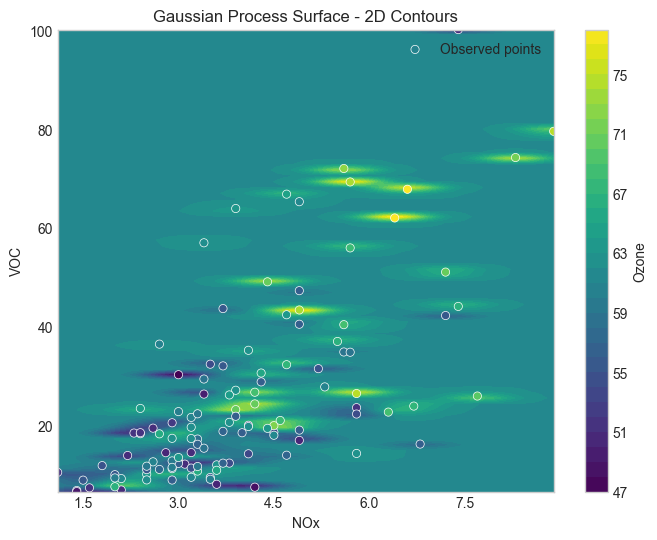

In [73]:
# 2D Contour Plot
plot_cfg = cfg['plot']
fig, ax = plt.subplots(figsize=(8, 6))
levels = plot_cfg['contour_levels']
contour = ax.contourf(lon_grid, lat_grid, value_grid, levels=levels, cmap=plot_cfg['cmap'])
scatter = ax.scatter(lon, lat, c=values, cmap=plot_cfg['cmap'], edgecolor='white', linewidth=0.5, s=plot_cfg['point_size'])

cbar = fig.colorbar(contour, ax=ax, label=value_col)
ax.set_xlabel(lon_col)
ax.set_ylabel(lat_col)
ax.set_title('Gaussian Process Surface - 2D Contours')
ax.legend([scatter], ['Observed points'], loc='best')
ax.xaxis.set_major_locator(ticker.MaxNLocator(6))
ax.yaxis.set_major_locator(ticker.MaxNLocator(6))
plt.show()


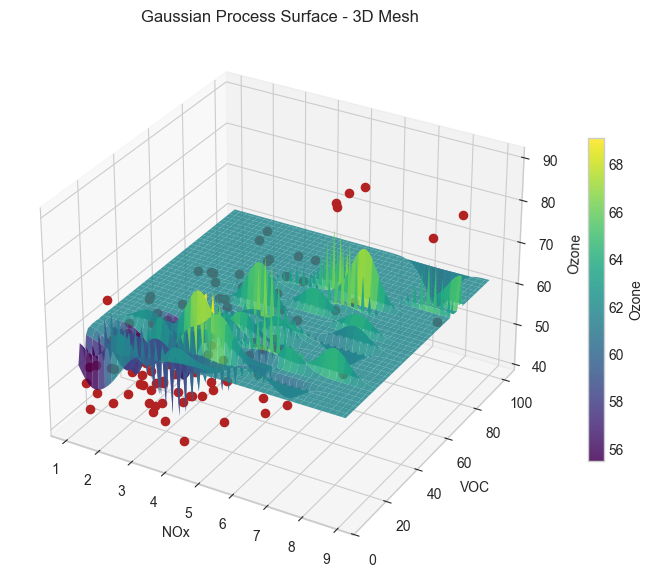

In [74]:
# Static 3D Surface Plot
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 - activates 3D projection

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
surface = ax.plot_surface(lon_grid, lat_grid, value_grid, cmap=plot_cfg['cmap'], alpha=plot_cfg['surface_alpha'], linewidth=0, antialiased=True)
ax.scatter(lon, lat, values, color=plot_cfg['scatter_color'], s=plot_cfg['point_size'], depthshade=False)

fig.colorbar(surface, ax=ax, shrink=0.6, label=value_col)
ax.set_xlabel(lon_col)
ax.set_ylabel(lat_col)
ax.set_zlabel(value_col)
ax.set_title('Gaussian Process Surface - 3D Mesh')
plt.show()


In [75]:
# Interactive 3D Plot (Plotly)
try:
    import plotly.graph_objects as go
except ImportError as exc:
    raise ImportError('Plotly is required for the interactive 3D view. Install it with `pip install plotly`.') from exc

plotly_scale = plot_cfg.get('plotly_colorscale') or plot_cfg['cmap'].capitalize()
marker_size = max(plot_cfg['point_size'] / 4, 4)

fig = go.Figure()
fig.add_surface(
    x=lon_grid,
    y=lat_grid,
    z=value_grid,
    colorscale=plotly_scale,
    opacity=plot_cfg['surface_alpha'],
    showscale=True,
    name='GPR surface',
)
fig.add_scatter3d(
    x=lon,
    y=lat,
    z=values,
    mode='markers',
    marker=dict(size=marker_size, color=values, colorscale=plotly_scale, line=dict(width=0.5, color='gray')),
    name='Observed points',
)
fig.update_layout(
    width=900,
    height=650,
    scene=dict(
        xaxis_title=lon_col,
        yaxis_title=lat_col,
        zaxis_title=value_col,
    ),
    title='Gaussian Process Surface - Interactive 3D',
)
fig.show()


In [78]:
# Hyperparameter Grid Search (RMSE minimization)
from itertools import product
import copy

def _unique_preserve(values):
    seen = set()
    ordered = []
    for item in values:
        if item not in seen:
            ordered.append(item)
            seen.add(item)
    return ordered

base_gpr = cfg.get('gpr', {})
base_kernel = dict(base_gpr.get('kernel', {}))

gpr_param_grid = {
    'alpha': _unique_preserve([
        i for i in np.linspace(0.01, 0.4, 4)
    ]),
    'kernel.type': _unique_preserve([
        base_kernel.get('type', 'RBF'),
        'RBF',
        'Matern',
        'RationalQuadratic',
    ]),
    'kernel.length_scale': _unique_preserve([
        i for i in np.linspace(0.5, 10, 4)
    ]),
    'kernel.white_noise': _unique_preserve([
        i for i in np.linspace(0.01,0.07,4)
    ]),
    'kernel.constant': _unique_preserve([
        i for i in np.linspace(0,2,4)
    ]),
}


def grid_search_gpr_params(lon_array, lat_array, value_array, base_cfg, param_grid, kfold_cfg):
    lon_array = np.asarray(lon_array, dtype=float)
    lat_array = np.asarray(lat_array, dtype=float)
    value_array = np.asarray(value_array, dtype=float)

    param_names = list(param_grid)
    combos = list(product(*param_grid.values()))
    rows = []

    for combo in combos:
        updates = dict(zip(param_names, combo))
        candidate = copy.deepcopy(base_cfg)
        kernel_updates = {}
        for key, value in updates.items():
            if key.startswith('kernel.'):
                kernel_updates[key.split('.', 1)[1]] = value
            else:
                candidate[key] = value

        candidate_kernel = dict(candidate.get('kernel', {}))
        candidate_kernel.update(kernel_updates)
        candidate['kernel'] = candidate_kernel

        try:
            fold_df = evaluate_gpr_kfold(
                lon_array,
                lat_array,
                value_array,
                candidate,
                kfold_cfg,
            )
            rows.append({
                **updates,
                'rmse_mean': fold_df['rmse'].mean(),
                'mae_mean': fold_df['mae'].mean(),
                'r2_mean': fold_df['r2'].mean(),
                'status': 'ok',
            })
        except Exception as exc:
            rows.append({
                **updates,
                'rmse_mean': np.inf,
                'mae_mean': np.inf,
                'r2_mean': np.nan,
                'status': f'failed: {exc}',
            })

    results = pd.DataFrame(rows)
    if not results.empty:
        results = results.sort_values(
            'rmse_mean',
            key=lambda values: np.where(np.isfinite(values), values, np.inf),
        ).reset_index(drop=True)
    return results


gpr_search_results = grid_search_gpr_params(lon, lat, values, base_gpr, gpr_param_grid, kfold_cfg)
print('Top candidate GPR settings (sorted by mean RMSE):')
display(gpr_search_results.head(10))

finite_mask = np.isfinite(gpr_search_results['rmse_mean']) if not gpr_search_results.empty else []
if np.any(finite_mask):
    best_gpr_params = gpr_search_results.loc[finite_mask].iloc[0].to_dict()
    print('Best GPR parameters based on cross-validated RMSE:')
    best_gpr_params
else:
    best_gpr_params = {}
    print('No successful parameter combinations were found. Inspect gpr_search_results for details.')


/Users/isaacsudweeks/Desktop/Work/Improved_Isopleths/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:305: RuntimeWarning:

divide by zero encountered in log

/Users/isaacsudweeks/Desktop/Work/Improved_Isopleths/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:305: RuntimeWarning:

divide by zero encountered in log

/Users/isaacsudweeks/Desktop/Work/Improved_Isopleths/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:305: RuntimeWarning:

divide by zero encountered in log

/Users/isaacsudweeks/Desktop/Work/Improved_Isopleths/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:305: RuntimeWarning:

divide by zero encountered in log

/Users/isaacsudweeks/Desktop/Work/Improved_Isopleths/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:305: RuntimeWarning:

divide by zero encountered in log

/Users/isaacsudweeks/Desktop/Work/Improved_Isopleths/.venv/lib/python3.12/site-packages/sklearn

Top candidate GPR settings (sorted by mean RMSE):


,alpha,kernel.type,kernel.length_scale,kernel.white_noise,kernel.constant,rmse_mean,mae_mean,r2_mean,status
0,0.14,RationalQuadratic,3.666667,0.03,0.000000,9.374009,7.918880,0.072158,ok
1,0.14,RationalQuadratic,0.500000,0.05,0.000000,9.446307,7.923132,0.056195,ok
2,0.14,RBF,3.666667,0.05,1.333333,9.464481,8.140871,0.044097,ok
3,0.14,RBF,0.500000,0.01,1.333333,9.464484,8.140872,0.044096,ok
4,0.27,RationalQuadratic,3.666667,0.03,0.000000,9.468420,8.085952,0.054712,ok
5,0.14,RationalQuadratic,0.500000,0.01,0.000000,9.483235,7.990093,0.046081,ok
6,0.01,Matern,10.000000,0.03,0.666667,9.495454,8.075588,0.042269,ok
7,0.14,RBF,0.500000,0.01,0.666667,9.496617,8.162468,0.040162,ok
8,0.40,RationalQuadratic,0.500000,0.01,0.666667,9.509434,7.980477,0.026775,ok
9,0.27,RationalQuadratic,6.833333,0.01,1.333333,9.512671,8.056603,0.028035,ok


Best GPR parameters based on cross-validated RMSE:
